In [5]:
using DifferentialEquations
using Plots

In [8]:
#temperature (assumed constant)
T = 1200 #K
P = 1e6 #Pa

R = 8.314 # J/molK

c_tot = P / (R*T) # ideal gas law

# Initial species concentrations 1. N2, 2. O2, 3. CH4, 4. H2O, 5. CO2
X0 = c_tot*[7.57/10.57, 2/10.57, 1/10.57, 0, 0] #mol/m^3, adiabatic mixture

n_O = X0[2]*2+X0[4]+X0[5]*2
n_C = X0[3]+X0[5]
n_H = X0[3]*4+X0[4]*2

println("Amount of O atoms: $n_O")
println("Amount of H atoms: $n_H")
println("Amount of C atoms: $n_C")

# 2*O2 + CH4 -> 2*H2O + CO2
S = [0, -2, -1, 2, 1]

function Arrhenius(T, X)
    # Constants from Westbrook & Dryer 1981
    n_CH4 = -0.3
    n_O2 = 1.3
    A = 1.3e8
    Ea = 48.4 * 4184 # kcal/mol to J/mol
    R = 8.314 # J/mol/K
    
    # Ensure positive concentrations for exponentiation
    CH4_concentration = max(X[3], 0) * 1e-6 # Arrhenius takes /cm3
    O2_concentration = max(X[2], 0) * 1e-6 # Arrhenius takes /cm3
    k = A * exp(-Ea / (R * T)) # rate constant
    r = k * CH4_concentration^n_CH4 * O2_concentration^n_O2 # reaction rate
    return r * 1e6 # Back to /m3
end


function f!(dX, X, p, t)
    r = Arrhenius(T, X)
    dX .= r .* S
end

# define time span 
tend = 10
tspan = (0, tend)

# define problem 
@time problem = ODEProblem(f!, X0, tspan)

# solve problem 
sol = solve(problem, alg_hints=[:stiff])

Amount of O atoms: 37.93095155785074
Amount of H atoms: 37.93095155785074
Amount of C atoms: 9.482737889462685
  0.000128 seconds (63 allocations: 2.328 KiB)


retcode: Success
Interpolation: 3rd order Hermite
t: 16-element Vector{Float64}:
  0.0
  0.00016672174453216033
  0.0018339391898537637
  0.018506113643069796
  0.1478055611922513
  0.46516693706049883
  0.9483862072212763
  1.5582201955197021
  2.3353047757495764
  3.250340627743154
  4.305034451029705
  5.4751544820057605
  6.750117887352834
  8.111817845233256
  9.548116683923437
 10.0
u: 16-element Vector{Vector{Float64}}:
 [71.78432582323252, 18.96547577892537, 9.482737889462685, 0.0, 0.0]
 [71.78432582323252, 18.963926737724506, 9.481963368862253, 0.0015490412008635965, 0.0007745206004317983]
 [71.78432582323252, 18.94844328265934, 9.47422164132967, 0.01703249626602872, 0.00851624813301436]
 [71.78432582323252, 18.79430232843503, 9.397151164217515, 0.1711734504903381, 0.08558672524516905]
 [71.78432582323252, 17.640677145614347, 8.820338572807174, 1.3247986333110218, 0.6623993166555109]
 [71.78432582323252, 15.100470682647666, 7.550235341323833, 3.8650050962777036, 1.932502548138

[18.96547577892537 9.482737889462685 0.0 0.0; 18.963926737724506 9.481963368862253 0.0015490412008635965 0.0007745206004317983; 18.94844328265934 9.47422164132967 0.01703249626602872 0.00851624813301436; 18.79430232843503 9.397151164217515 0.1711734504903381 0.08558672524516905; 17.640677145614347 8.820338572807174 1.3247986333110218 0.6623993166555109; 15.100470682647666 7.550235341323833 3.8650050962777036 1.9325025481388518; 11.91725554351749 5.958627771758745 7.04822023540788 3.52411011770394; 8.83939057575185 4.419695287875925 10.12608520317352 5.06304260158676; 6.040637588230152 3.020318794115076 12.924838190695219 6.4624190953476095; 3.8582637991076973 1.9291318995538487 15.107211979817674 7.553605989908837; 2.301374797935962 1.150687398967981 16.66410098098941 8.332050490494705; 1.2972562799396516 0.6486281399698258 17.66821949898572 8.83410974949286; 0.694640805727923 0.3473204028639615 18.27083497319745 9.135417486598724; 0.35648777596965936 0.17824388798482968 18.60898800295

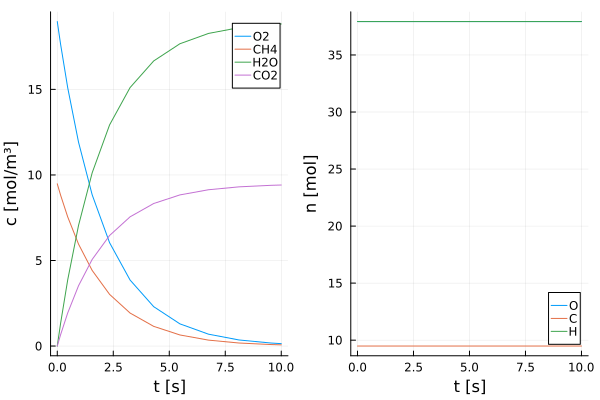

"C:\\Users\\jelte\\chemicalcombustion\\Toy Models\\1stepnoT.png"

In [14]:
times=sol.t
n_times=length(times)

u=Array{Float64}(undef, n_times, 4)

n_O=[]
n_C=[]
n_H=[]
    
for (i, u_vec) in enumerate(sol.u)
    u[i,:]=u_vec[2:end]
    push!(n_O, u_vec[2]*2+u_vec[4]+u_vec[5]*2)
    push!(n_C, u_vec[3]+u_vec[5])
    push!(n_H, u_vec[3]*4+u_vec[4]*2)
end

t=sol.t

println(u)

# plot solution obtained 
plot1 = plot(t,u, xaxis="t [s]", yaxis="c [mol/m³]", label=["O2" "CH4" "H2O" "CO2"])
plot2 = plot(t, n_O, xaxis="t [s]", yaxis="n [mol]", label="O")
plot!(plot2, t, n_C, xaxis="t [s]", yaxis="n [mol]", label="C")
plot!(plot2, t, n_H, xaxis="t [s]", yaxis="n [mol]", label="H")
plots=plot(plot1, plot2, legend=true)
display(plots)
savefig("1stepnoT")